# JSON Dataset Analysis and Visualization

This notebook loads the nested capture/entity JSON structure, flattens it into analysis-friendly pandas DataFrames, computes summaries, and produces plots for classes, entities per capture, distance, masks, bounding boxes, weather, daytime, temperature, and spatial positions.

**Usage:** change `JSON_PATH` below to your JSON file, then run all cells.


In [1]:
# Configuration
JSON_PATH = "D:/rdr_dataset_12/all_captures_with_weather_3.json"  # <-- change this to your JSON file
TOP_N = 200               # number of categories shown in categorical plots


In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

path = Path(JSON_PATH)
if not path.exists():
    raise FileNotFoundError(f"JSON file not found: {path.resolve()}")

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Loaded {len(data):,} captures from {path}")


Loaded 23,806 captures from D:\rdr_dataset_12\all_captures_with_weather_3.json


In [3]:
# Flatten captures and entities into two analysis-friendly tables

def safe_get(d, key, default=np.nan):
    return d.get(key, default) if isinstance(d, dict) else default

def vec3(value):
    if isinstance(value, list):
        return (value + [np.nan, np.nan, np.nan])[:3]
    return [np.nan, np.nan, np.nan]

capture_rows = []
entity_rows = []

for capture_key, record in data.items():
    capture = record.get("Capture", {})
    capture_id = safe_get(capture, "ID", capture_key)

    position = vec3(safe_get(capture, "Position", None))
    rotation = vec3(safe_get(capture, "CameraRotation", None))

    row = dict(capture)
    row.update({
        "CaptureKey": capture_key,
        "CaptureID": capture_id,
        "PositionX": position[0],
        "PositionY": position[1],
        "PositionZ": position[2],
        "CameraRotationX": rotation[0],
        "CameraRotationY": rotation[1],
        "CameraRotationZ": rotation[2],
    })
    capture_rows.append(row)

    for entity in record.get("Entities", []) or []:
        e = dict(entity)
        e["CaptureKey"] = capture_key
        e["CaptureID"] = capture_id
        e["CaptureWeather"] = safe_get(capture, "Weather")
        e["CaptureWeatherPredicted"] = safe_get(capture, "Weather_Predicted")
        e["CaptureDaytime"] = safe_get(capture, "Daytime")
        e["CaptureDaytimeCategory"] = safe_get(capture, "DaytimeCategory")
        e["CaptureTemperature"] = safe_get(capture, "Temperature")
        e["CaptureZone"] = safe_get(capture, "Zone")
        e["CaptureFOV"] = safe_get(capture, "CameraFOV")
        e["CaptureAboveGround"] = safe_get(capture, "CameraAboveGround")
        e["CaptureDistanceToPlayer"] = safe_get(capture, "CameraDistanceToPlayer")

        pos = vec3(safe_get(entity, "Position", None))
        e["EntityPositionX"], e["EntityPositionY"], e["EntityPositionZ"] = pos

        dims_min = vec3(safe_get(entity, "DimensionsMin", None))
        dims_max = vec3(safe_get(entity, "DimensionsMax", None))
        e["DimensionX"] = dims_max[0] - dims_min[0]
        e["DimensionY"] = dims_max[1] - dims_min[1]
        e["DimensionZ"] = dims_max[2] - dims_min[2]

        bbox = safe_get(entity, "BoundingBoxCalculated", None)
        if isinstance(bbox, list) and len(bbox) >= 4:
            x1, y1, x2, y2 = bbox[:4]
            e["BBoxX1"], e["BBoxY1"], e["BBoxX2"], e["BBoxY2"] = x1, y1, x2, y2
            e["BoundingBoxWidth"] = abs(x2 - x1)
            e["BoundingBoxHeight"] = abs(y2 - y1)
            e["BoundingBoxArea"] = abs(x2 - x1) * abs(y2 - y1)
        else:
            e["BBoxX1"] = e["BBoxY1"] = e["BBoxX2"] = e["BBoxY2"] = np.nan
            e["BoundingBoxWidth"] = e["BoundingBoxHeight"] = e["BoundingBoxArea"] = np.nan

        entity_rows.append(e)

captures = pd.DataFrame(capture_rows)
entities = pd.DataFrame(entity_rows)

print(f"Captures table: {captures.shape[0]:,} rows × {captures.shape[1]:,} columns")
print(f"Entities table: {entities.shape[0]:,} rows × {entities.shape[1]:,} columns")


Captures table: 23,806 rows × 32 columns
Entities table: 58,622 rows × 48 columns


In [ ]:
# Dataset overview
print("CAPTURE SUMMARY")
display(captures.describe(include="all").T)

print("ENTITY SUMMARY")
display(entities.describe(include="all").T)

entity_counts = entities.groupby("CaptureID").size()
print(f"Total captures: {len(captures):,}")
print(f"Total entities: {len(entities):,}")
print(f"Average entities/capture: {entity_counts.mean():.2f}")
print(f"Maximum entities/capture: {entity_counts.max():,}")


CAPTURE SUMMARY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CameraAboveGround,23806.0,NaN,NaN,NaN,21.016236,25.217775,-7.261754,4.115219,16.882721,31.918252,458.237213
CameraDistanceToPlayer,23806.0,NaN,NaN,NaN,114.017306,57.547884,2.663861,81.978348,108.824402,142.053684,4524.146973
CameraFOV,23806.0,NaN,NaN,NaN,70.0,0.0,70.0,70.0,70.0,70.0,70.0
CameraRotation,23806,21896,"[0.0, 0.0, 0.20284266769886017]",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daytime,23806,1024,12:0:20,9724,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DaytimeCategory,23806,6,noon,23289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DepthImagePath,23806,1,00_Original.exr,23806,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EntityCount,23806.0,NaN,NaN,NaN,2.462488,2.277992,0.0,1.0,2.0,4.0,29.0
Exposure,23806.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HDRImagePath,23806,1705,126_Original.jxr,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN


NameError: name 'entity_counts' is not defined

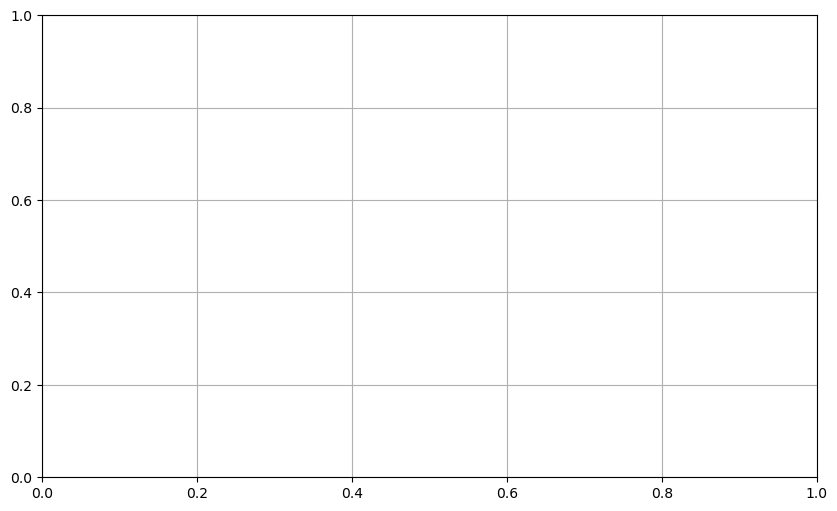

In [4]:
# Entities per capture
fig, ax = plt.subplots()
ax.hist(entity_counts, bins=30)
ax.set_title("Entities per Capture")
ax.set_xlabel("Number of entities")
ax.set_ylabel("Number of captures")
plt.show()


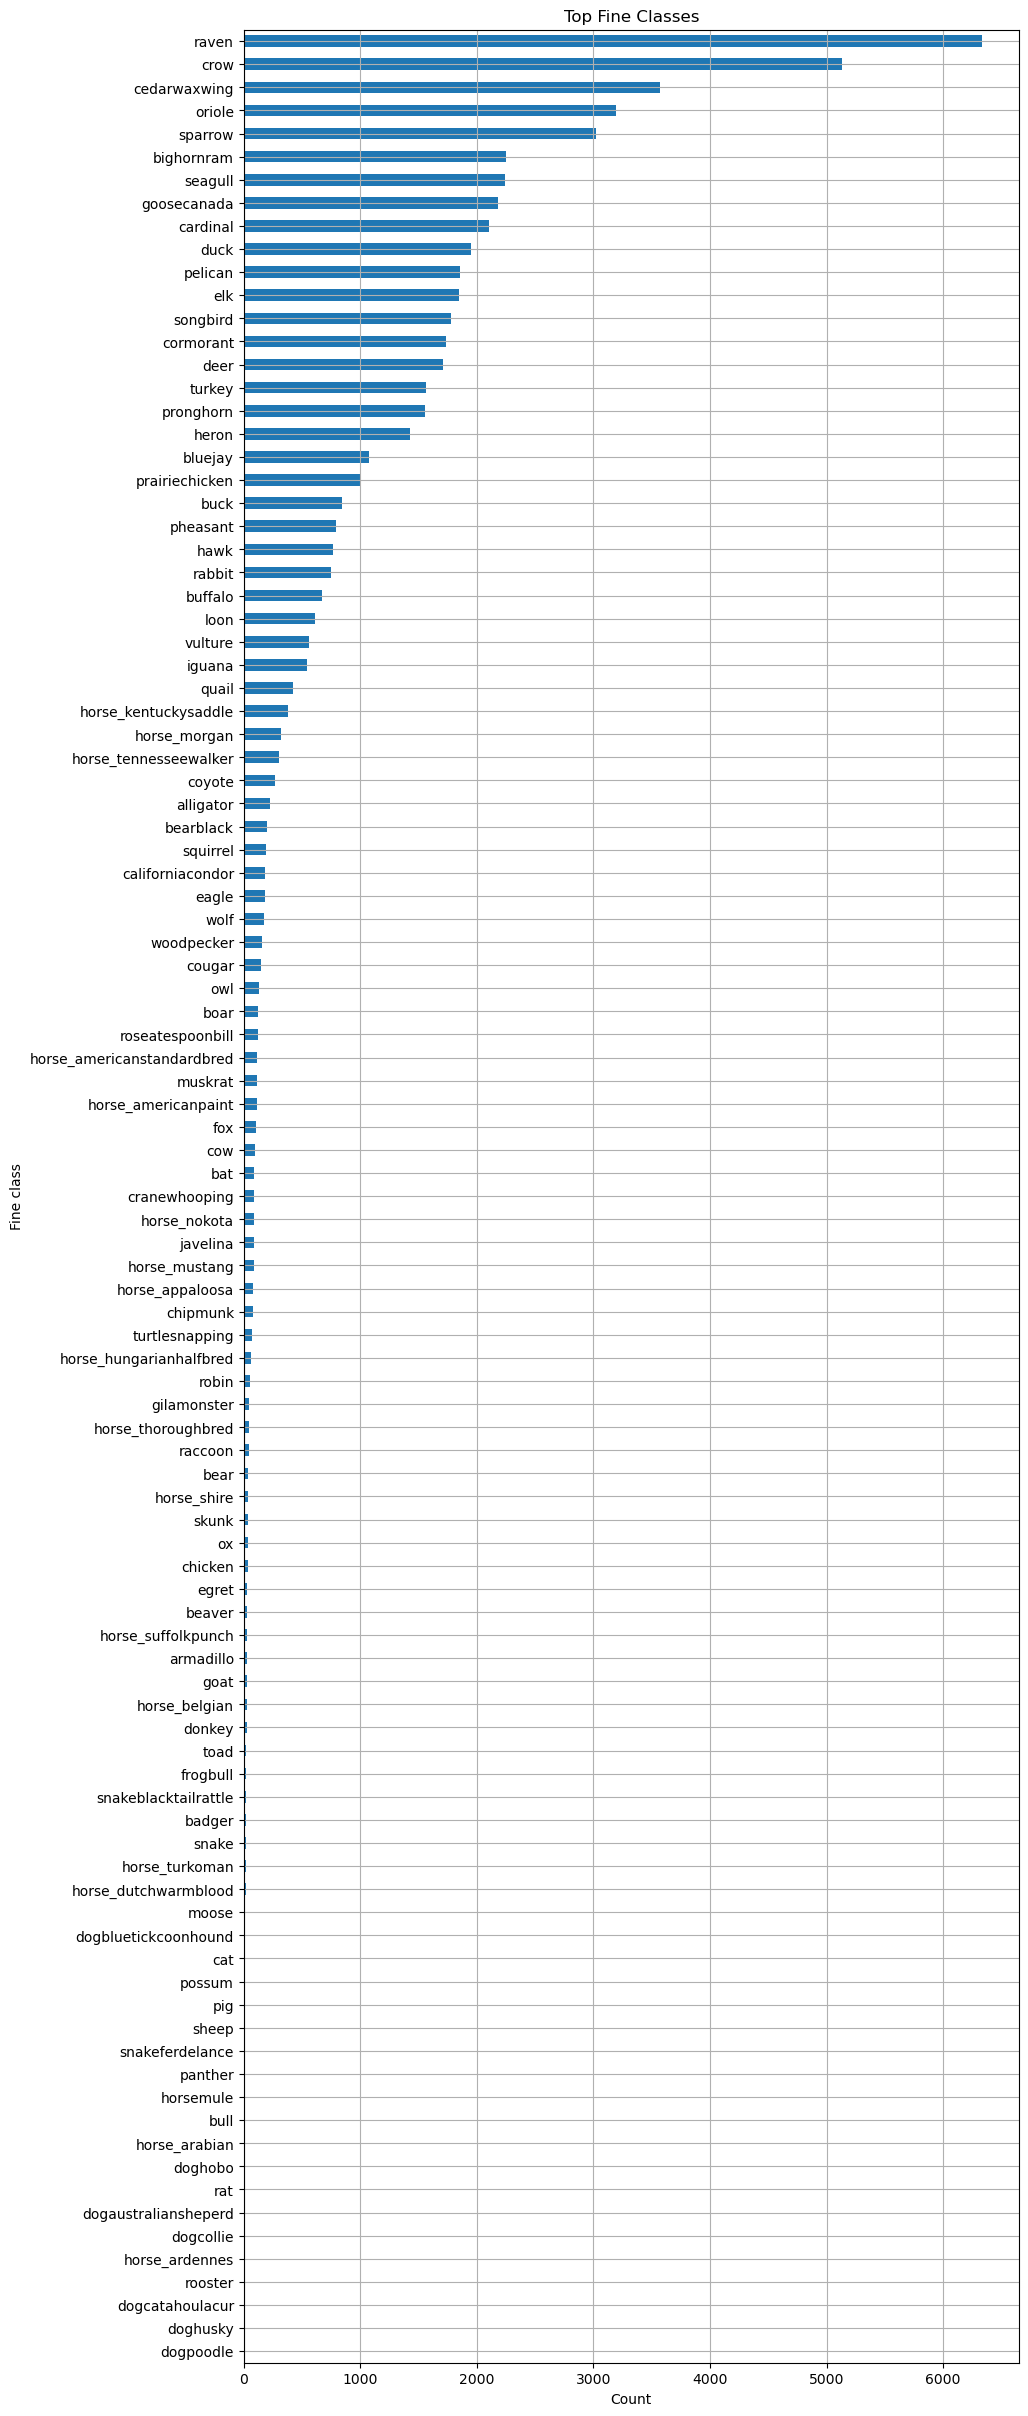

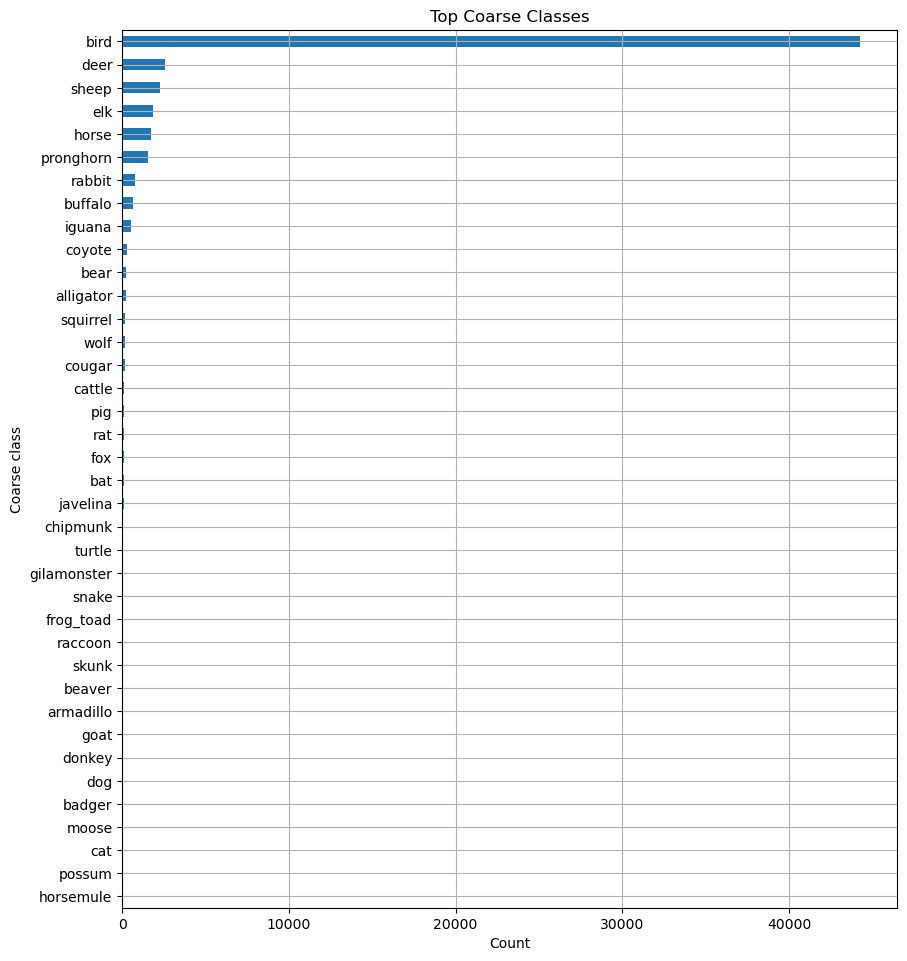

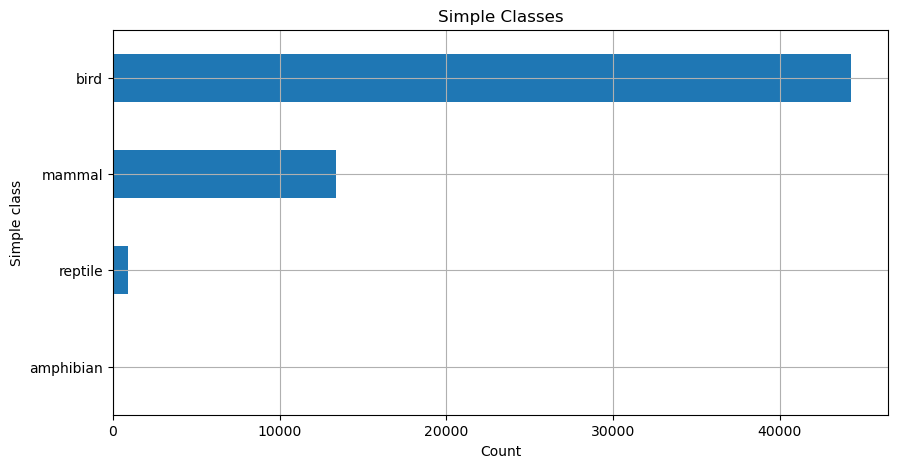

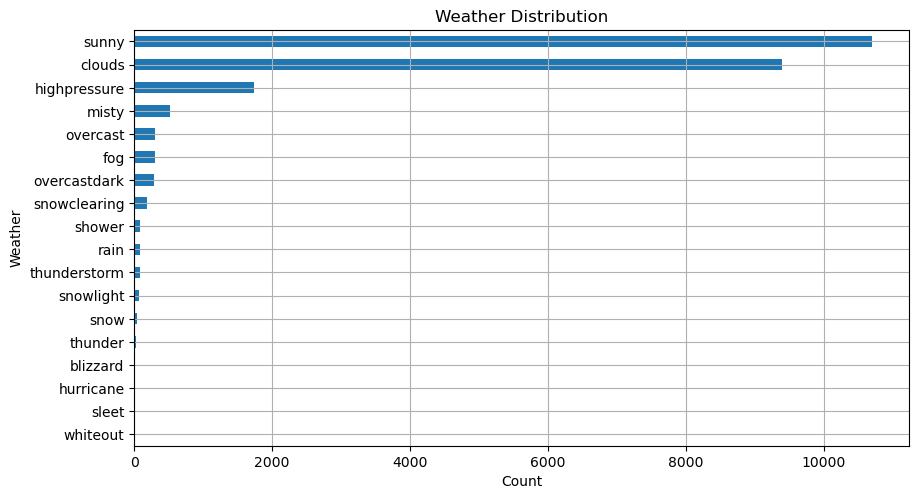

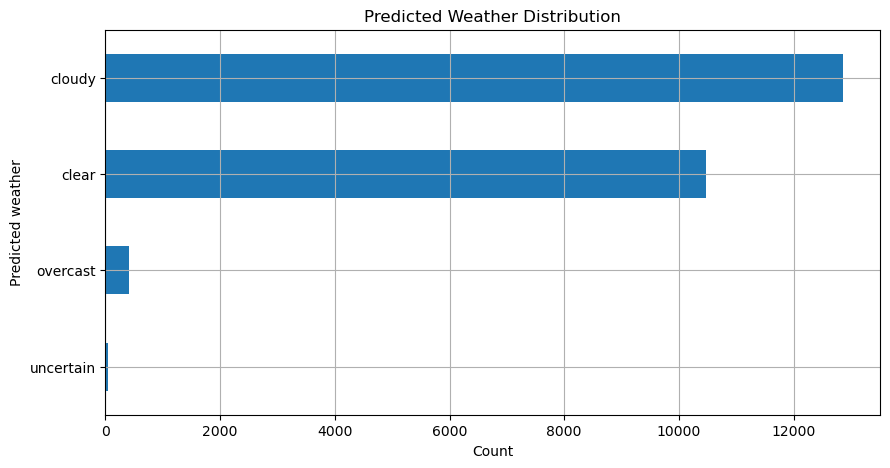

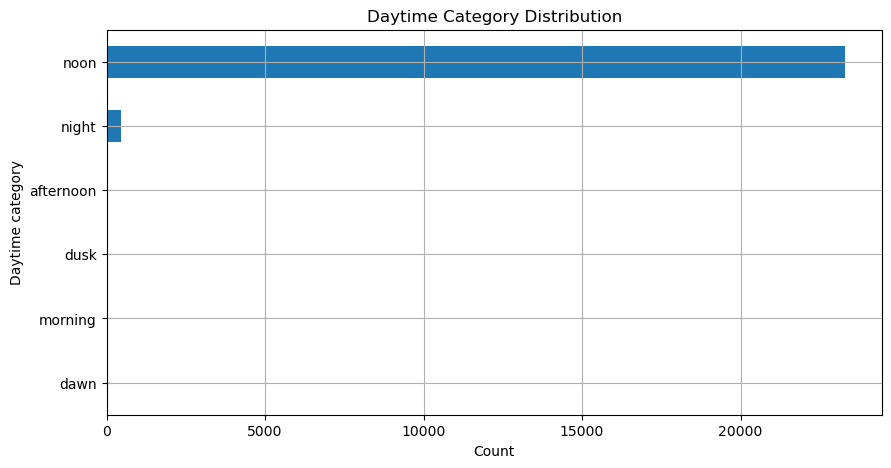

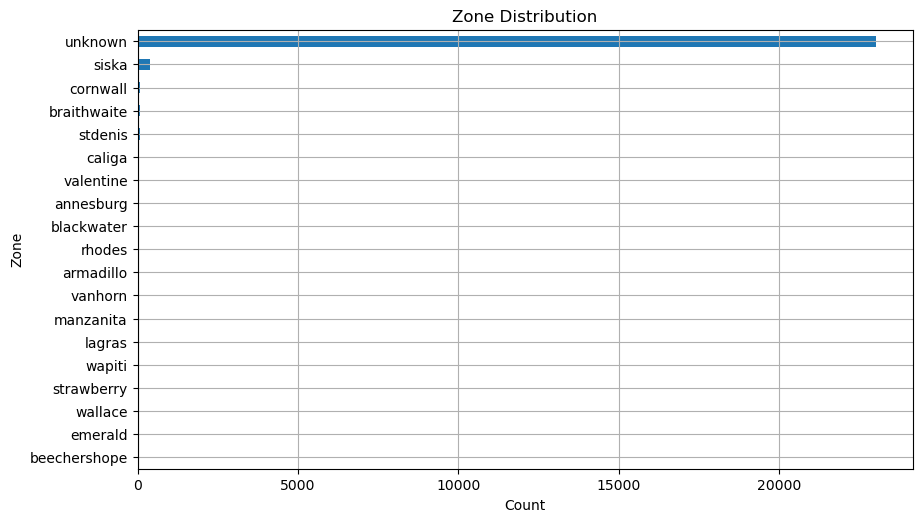

In [5]:
# Categorical distributions

def plot_top_counts(series, title, xlabel, top_n=TOP_N):
    counts = series.dropna().astype(str).value_counts()
    if top_n is not None:
        counts = counts.head(top_n)
    ax = counts.sort_values().plot(
        kind="barh",
        figsize=(10, max(5, len(counts) * 0.3))
    )
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel(xlabel)
    plt.show()

plot_top_counts(entities["FineClassName"], "Top Fine Classes", "Fine class")
plot_top_counts(entities["CoarseClassName"], "Top Coarse Classes", "Coarse class")
plot_top_counts(entities["SimpleClassName"], "Simple Classes", "Simple class")
plot_top_counts(captures["Weather"], "Weather Distribution", "Weather")
plot_top_counts(captures["Weather_Predicted"], "Predicted Weather Distribution", "Predicted weather")
plot_top_counts(captures["DaytimeCategory"], "Daytime Category Distribution", "Daytime category")
plot_top_counts(captures["Zone"], "Zone Distribution", "Zone")


In [ ]:
# Entity distance distribution
entities["Distance"] = pd.to_numeric(entities["Distance"], errors="coerce")

fig, ax = plt.subplots()
ax.hist(entities["Distance"].dropna(), bins=50)
ax.set_title("Entity Distance Distribution")
ax.set_xlabel("Distance")
ax.set_ylabel("Entity count")
plt.show()

display(entities["Distance"].describe())


In [ ]:
# Distance by the most common fine classes
top_classes = entities["FineClassName"].value_counts().head(TOP_N).index
tmp = entities[entities["FineClassName"].isin(top_classes)].copy()

fig, ax = plt.subplots(figsize=(12, 7))
tmp.boxplot(column="Distance", by="FineClassName", ax=ax, rot=75)
ax.set_title("Distance by Fine Class")
ax.set_xlabel("Fine class")
ax.set_ylabel("Distance")
plt.suptitle("")
plt.tight_layout()
plt.show()


In [ ]:
# Mask and bounding-box relationships
for col in [
    "PercentageMaskImage", "PercentageMaskBbox",
    "BoundingBoxArea", "BoundingBoxWidth", "BoundingBoxHeight",
    "HeightAboveGround"
]:
    if col in entities:
        entities[col] = pd.to_numeric(entities[col], errors="coerce")

fig, ax = plt.subplots()
ax.scatter(
    entities["Distance"],
    entities["PercentageMaskImage"],
    alpha=0.4
)
ax.set_title("Distance vs. Percentage of Image Covered by Entity Mask")
ax.set_xlabel("Distance")
ax.set_ylabel("Mask percentage")
plt.show()

fig, ax = plt.subplots()
valid = entities["BoundingBoxArea"] > 0
ax.scatter(
    entities.loc[valid, "Distance"],
    entities.loc[valid, "BoundingBoxArea"],
    alpha=0.4
)
ax.set_title("Distance vs. Bounding Box Area")
ax.set_xlabel("Distance")
ax.set_ylabel("Bounding box area (pixels²)")
ax.set_yscale("log")
plt.show()


In [ ]:
# Camera and environmental variables
for col in [
    "CameraAboveGround", "CameraDistanceToPlayer",
    "CameraFOV", "Temperature", "Exposure"
]:
    if col in captures:
        captures[col] = pd.to_numeric(captures[col], errors="coerce")

available = [
    c for c in [
        "CameraAboveGround", "CameraDistanceToPlayer",
        "CameraFOV", "Temperature", "Exposure"
    ] if c in captures.columns
]

display(captures[available].describe().T)

fig, ax = plt.subplots()
ax.scatter(captures["Temperature"], captures["EntityCount"], alpha=0.5)
ax.set_title("Temperature vs. Recorded Entity Count")
ax.set_xlabel("Temperature")
ax.set_ylabel("Entity count")
plt.show()

fig, ax = plt.subplots()
ax.scatter(
    captures["CameraDistanceToPlayer"],
    captures["EntityCount"],
    alpha=0.5
)
ax.set_title("Camera Distance to Player vs. Entity Count")
ax.set_xlabel("Camera distance to player")
ax.set_ylabel("Entity count")
plt.show()


In [ ]:
# Weather and daytime versus entity counts
capture_entity_counts = entities.groupby("CaptureID").size().rename("ActualEntityCount")
env = captures.set_index("CaptureID").join(capture_entity_counts).reset_index()

weather_stats = (
    env.groupby("Weather")["ActualEntityCount"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)
display(weather_stats)

day_stats = (
    env.groupby("DaytimeCategory")["ActualEntityCount"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)
display(day_stats)

fig, ax = plt.subplots()
env.boxplot(column="ActualEntityCount", by="Weather", ax=ax, rot=60)
ax.set_title("Entity Count by Weather")
ax.set_xlabel("Weather")
ax.set_ylabel("Entities per capture")
plt.suptitle("")
plt.tight_layout()
plt.show()


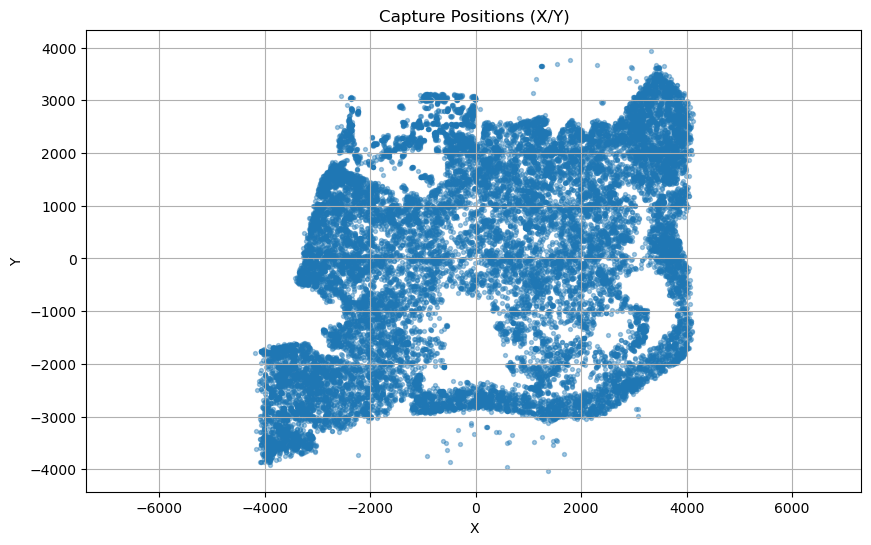

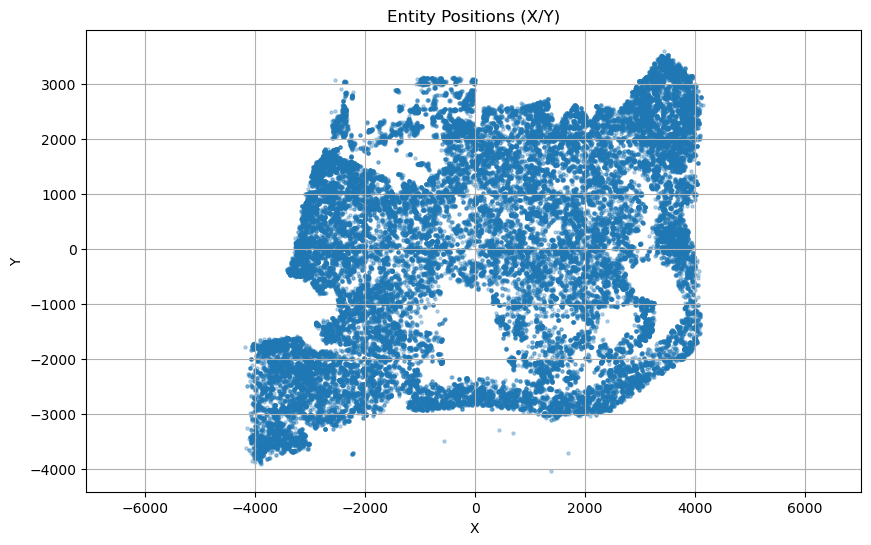

In [6]:
# Spatial distribution
fig, ax = plt.subplots()
ax.scatter(captures["PositionX"], captures["PositionY"], s=8, alpha=0.4)
ax.set_title("Capture Positions (X/Y)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_aspect("equal", adjustable="datalim")
plt.show()

fig, ax = plt.subplots()
ax.scatter(
    entities["EntityPositionX"],
    entities["EntityPositionY"],
    s=5,
    alpha=0.3
)
ax.set_title("Entity Positions (X/Y)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_aspect("equal", adjustable="datalim")
plt.show()


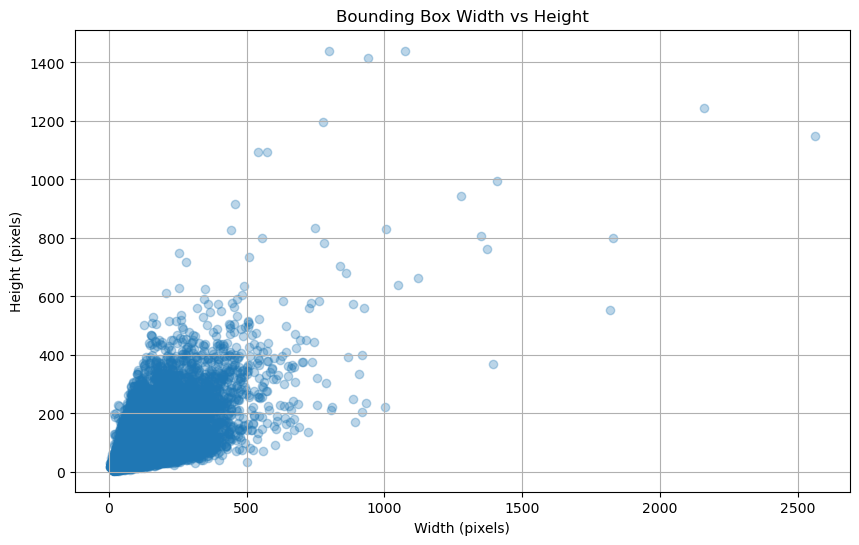

count    58622.000000
mean         1.669236
std          0.859934
min          0.106599
25%          1.094377
50%          1.492958
75%          2.038462
max         15.242424
Name: BBoxAspectRatio, dtype: float64

In [7]:
# Bounding-box dimensions and aspect ratio
fig, ax = plt.subplots()
ax.scatter(
    entities["BoundingBoxWidth"],
    entities["BoundingBoxHeight"],
    alpha=0.3
)
ax.set_title("Bounding Box Width vs Height")
ax.set_xlabel("Width (pixels)")
ax.set_ylabel("Height (pixels)")
plt.show()

entities["BBoxAspectRatio"] = (
    entities["BoundingBoxWidth"] /
    entities["BoundingBoxHeight"].replace(0, np.nan)
)

display(entities["BBoxAspectRatio"].describe())


In [ ]:
# Validate recorded EntityCount against actual entity records
comparison = captures[["CaptureID", "EntityCount"]].copy()
comparison["EntityRecords"] = (
    comparison["CaptureID"]
    .map(entities.groupby("CaptureID").size())
    .fillna(0)
    .astype(int)
)
comparison["Difference"] = (
    comparison["EntityCount"] - comparison["EntityRecords"]
)

display(comparison.head(20))
print(
    "Captures where counts disagree:",
    int((comparison["Difference"] != 0).sum())
)


In [ ]:
# Optional: export flattened tables
OUTPUT_DIR = Path("analysis_output")
OUTPUT_DIR.mkdir(exist_ok=True)

captures.to_csv(OUTPUT_DIR / "captures_flat.csv", index=False)
entities.to_csv(OUTPUT_DIR / "entities_flat.csv", index=False)
comparison.to_csv(OUTPUT_DIR / "entity_count_comparison.csv", index=False)

print(f"Saved CSV tables to: {OUTPUT_DIR.resolve()}")
